# FREIA detector data

Visualize detector images, arrival-time distributions, and wavelength spectra. Wavelengths are reconstructed using the WFM chopper settings.

In [1]:
%matplotlib widget
import plopp as pp
import scipp as sc

from ess import freia
from ess.freia import data
from ess.reduce.nexus.types import DiskChoppers, Filename, RawDetector
from ess.reduce.unwrap import (
    ChopperFrameSequence,
    DistanceResolution,
    PulsePeriod,
    TimeResolution,
    WavelengthDetector,
)
from ess.reduce.unwrap.types import KeepEventTimeOffset
from ess.reflectometry.types import SampleRun

## Select a run

Download the example sample run and set the resolution used to reconstruct wavelengths. The file is cached locally by `pooch` (`pip install pooch`). To use your own data, replace the download function with a file path.

In [2]:
freia_mcstas = freia.FreiaMcStasWorkflow(wavelength_from='analytical')
freia_mcstas[Filename[SampleRun]] = data.freia_mcstas_reference_run()
freia_mcstas[KeepEventTimeOffset] = True
freia_mcstas[TimeResolution] = sc.scalar(20.0, unit='us')
freia_mcstas[DistanceResolution] = sc.scalar(0.1, unit='m')

## Inspect the WFM chopper cascade

Inspect the chopper timing used to reconstruct wavelengths. For a non-WFM run, call `freia_mcstas.insert(freia.mcstas.non_wfm_choppers)` before computing wavelengths. Other configurations can be assigned to `freia_mcstas[DiskChoppers[SampleRun]]`.

In [3]:
choppers = freia_mcstas.compute(DiskChoppers[SampleRun])
sc.DataGroup(choppers)

DataGroup(sizes={}, keys=[
    WBC1: DiskChopper(axle_position=<scipp.Variable> ()    vector3              [m]  (-0.0255362, -0.214349, 6.31387), frequency=<scipp.Variable> ()    float64             [Hz]  14, beam_position=<scipp.Variable> ()    float64            [deg]  0, phase=<scipp.Variable> ()    float64            [deg]  0, slit_begin=<scipp.Variable> (cutout: 1)    float64            [deg]  [265.753], slit_end=<scipp.Variable> (cutout: 1)    float64            [deg]  [347.42], slit_height=None, radius=None),
    PSC1: DiskChopper(axle_position=<scipp.Variable> ()    vector3              [m]  (-0.0427933, -0.248783, 7.32524), frequency=<scipp.Variable> ()    float64             [Hz]  56, beam_position=<scipp.Variable> ()    float64            [deg]  0, phase=<scipp.Variable> ()    float64            [deg]  0, slit_begin=<scipp.Variable> (cutout: 7)    float64            [deg]  [225.051, 174.313, ..., 353.033, 314.328], slit_end=<scipp.Variable> (cutout: 7)    float64            [deg]  [231.971, 183.05, ..., 369.57, 331.236], slit_height=None, radius=None),
    PSC2: DiskChopper(axle_position=<scipp.Variable> ()    vector3              [m]  (-0.0503614, -0.261212, 7.6903), frequency=<scipp.Variable> ()    float64             [Hz]  56, beam_position=<scipp.Variable> ()    float64            [deg]  0, phase=<scipp.Variable> ()    float64            [deg]  0, slit_begin=<scipp.Variable> (cutout: 7)    float64            [deg]  [218.759, 165.577, ..., 335.626, 295.005], slit_end=<scipp.Variable> (cutout: 7)    float64            [deg]  [225.68, 174.313, ..., 352.163, 311.913], slit_height=None, radius=None),
    PSC3: DiskChopper(axle_position=<scipp.Variable> ()    vector3              [m]  (-0.067289, -0.285092, 8.39169), frequency=<scipp.Variable> ()    float64             [Hz]  56, beam_position=<scipp.Variable> ()    float64            [deg]  0, phase=<scipp.Variable> ()    float64            [deg]  0, slit_begin=<scipp.Variable> (cutout: 7)    float64            [deg]  [206.141, 148.791, ..., 302.334, 256.568], slit_end=<scipp.Variable> (cutout: 7)    float64            [deg]  [218.897, 162.225, ..., 321.812, 277.595], slit_height=None, radius=None),
    WBC2: DiskChopper(axle_position=<scipp.Variable> ()    vector3              [m]  (-0.0863302, -0.31394, 9.23899), frequency=<scipp.Variable> ()    float64             [Hz]  14, beam_position=<scipp.Variable> ()    float64            [deg]  0, phase=<scipp.Variable> ()    float64            [deg]  0, slit_begin=<scipp.Variable> (cutout: 1)    float64            [deg]  [227.076], slit_end=<scipp.Variable> (cutout: 1)    float64            [deg]  [339.967], slit_height=None, radius=None),
    PSC4: DiskChopper(axle_position=<scipp.Variable> ()    vector3              [m]  (-0.105167, -0.350514, 10.3132), frequency=<scipp.Variable> ()    float64             [Hz]  42, beam_position=<scipp.Variable> ()    float64            [deg]  0, phase=<scipp.Variable> ()    float64            [deg]  0, slit_begin=<scipp.Variable> (cutout: 7)    float64            [deg]  [218.217, 166.565, ..., 337.891, 297.674], slit_end=<scipp.Variable> (cutout: 7)    float64            [deg]  [238.933, 186.294, ..., 360.044, 317.961], slit_height=None, radius=None),
    PSC5: DiskChopper(axle_position=<scipp.Variable> ()    vector3              [m]  (-0.115146, -0.53099, 15.614), frequency=<scipp.Variable> ()    float64             [Hz]  28, beam_position=<scipp.Variable> ()    float64            [deg]  0, phase=<scipp.Variable> ()    float64            [deg]  0, slit_begin=<scipp.Variable> (cutout: 7)    float64            [deg]  [220.382, 168.493, ..., 344.653, 303.481], slit_end=<scipp.Variable> (cutout: 7)    float64            [deg]  [251.373, 197.687, ..., 366.102, 323.645], slit_height=None, radius=None),
    WBC3: DiskChopper(axle_position=<scipp.Variable> ()    vector3              [m]  (-0.10215, -0.590536, 17.3629), frequency=<scipp.Variable> ()    float64             [Hz]  14, beam_positio

(<Figure size 640x480 with 1 Axes>,
 <Axes: title={'center': 'Frame propagation through chopper cascade'}, xlabel='ms', ylabel='Å'>)

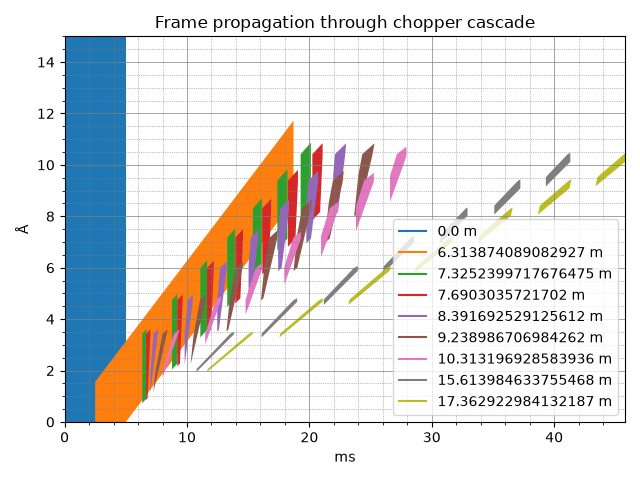

In [4]:
frames = freia_mcstas.compute(ChopperFrameSequence[SampleRun])
frames.draw()

## Load and unwrap the detector events

Compute wavelengths from the event arrival times and chopper transmission bands.

In [5]:
results = freia_mcstas.compute((RawDetector[SampleRun], WavelengthDetector[SampleRun]))
raw = results[RawDetector[SampleRun]]
unwrapped = results[WavelengthDetector[SampleRun]]
raw

<scipp.DataArray>
Dimensions: Sizes[pixel_id:131072, ]
Coordinates:
* height                    float64              [m]  (pixel_id)  [-0.147656, -0.147656, ..., 0.147656, 0.147656]
* longitude                 float64            [deg]  (pixel_id)  [-3.99805, -3.99414, ..., 3.99414, 3.99805]
* pixel_id                    int64        <no unit>  (pixel_id)  [0, 1, ..., 131070, 131071]
* position                  vector3              [m]  (pixel_id)  [(0.107903, -0.983566, 25.7558), (0.107903, -0.983361, 25.7559), ..., (-0.187507, -0.565509, 25.758), (-0.187507, -0.565305, 25.758)]
Data:
                          DataArrayView        <no unit>  (pixel_id)  binned data: dim='event', content=DataArray(
          dims=(event: 553856),
          data=float64[counts],
          coords={'event_time_offset':float64[s], 'event_time_zero':datetime64[ns],
                  'wavelength_from_mcstas':float64[Å]})

## Detector image and arrival times

The image uses `longitude` and `height` in the detector's local frame. Intensities are sums of event weights.

In [6]:
detector_image = raw.hist(longitude=120, height=64, dim=raw.dims)
pp.plot(detector_image, norm='log', title='FREIA detector', vmin=1e-1)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [7]:
pulse_period = freia_mcstas.compute(PulsePeriod).to(unit='s').value
arrival_times = raw.hist(
    event_time_offset=sc.linspace(
        'event_time_offset', 0.0, pulse_period, 501, unit='s'
    ),
    dim=raw.dims,
)
arrival_times.coords['event_time_offset'] = arrival_times.coords[
    'event_time_offset'
].to(unit='ms')
pp.plot(arrival_times, title='Arrival time within the source period')

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Wavelengths from analytical frame unwrapping

The chopper cascade and arrival times determine the wavelengths. Events outside the modeled transmission bands or above the workflow's relative wavelength uncertainty threshold have NaN wavelengths and do not contribute to the wavelength histograms. Inspect the assigned-event count when assessing the result.

In [8]:
valid = sc.isfinite(unwrapped.bins.coords['wavelength'])
print(f'{sc.sum(valid).value:,} / {valid.bins.size().sum().value:,} events have an assigned wavelength')

wavelength_bins = sc.linspace('wavelength', 1.0, 12.0, 441, unit='angstrom')
spectrum = unwrapped.hist(wavelength=wavelength_bins, dim=unwrapped.dims)
pp.plot(spectrum, title='FREIA wavelength spectrum')

548,132 / 553,856 events have an assigned wavelength


InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

In [9]:
wavelength_image = unwrapped.hist(
    wavelength=wavelength_bins, longitude=120, dim=unwrapped.dims
)
pp.plot(wavelength_image, norm='log', title='Wavelength across the detector', vmin=1e0)

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…

## Error of the wavelength estimate

McStas provides the true wavelengths of the neutron events in addition to the time of arrival.
We can use that to compare our wavelength estimates to the true wavelength values to figure out the accuracy of the estimates.

It is expected that the wavelength resolution for FREIA in WFM mode should be <2%.

In [10]:
unwrapped.bins.coords['wavelength_error'] = (
    (unwrapped.bins.coords['wavelength'] - unwrapped.bins.coords['wavelength_from_mcstas']) /
    unwrapped.bins.coords['wavelength_from_mcstas']
)
unwrapped.hist(wavelength_error=sc.linspace('wavelength_error', -0.02, 0.02, 100), dim=unwrapped.dims).plot()

InteractiveFigure(children=(HBar(), HBar(children=(VBar(children=(Toolbar(children=(ButtonTool(icon='home', la…